In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from classy_altered.classy import Class as Class_altered
import matplotlib as mpl
plt.rcParams.update(plt.rcParamsDefault)
from padé import combined_full_model
import os
import pandas as pd
from scipy.interpolate import interp1d
import timeit
from final_NN import get_emulator_prediction

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "xtick.top": True,
    "ytick.right": True,
})

In [2]:
cosmo_clean_DRMD = Class()
cosmo_clean_LCDM = Class()
cosmo_altered_DRMD = Class_altered()
cosmo_altered_LCDM = Class_altered()
cosmo_clean_hmcode_DRMD = Class()
cosmo_clean_hmcode_LCDM = Class()

# Set up the DRMD parameters
# Make sure 'yes' is the correct string to activate your boolean in your input file!
zPk = "5.0, 4.0, 3.0, 2.0, 1.0, 0.0"
k_targets = np.array([0.05, 1.0])   # 1/Mpc
kstr = ",".join(str(x) for x in k_targets[::-1])

LCDM_params = {
    'h': 0.6766,
    'omega_b': 0.02242,
    'omega_cdm': 0.1192,
    'A_s': 2.107699e-9,
    'n_s': 0.9671182,
    'output': 'dTk, mPk, vTk',
    'lensing': 'no',

    # neutrino sector (your baseline)
    'N_ur': 2.0328,
    'N_ncdm': 1,
    'deg_ncdm': 1,
    'm_ncdm': 0.06,
    'T_ncdm': 0.71611,

    'YHe': 0.245,

    'z_pk': zPk,
    'k_output_values': kstr,
    'P_k_max_1/Mpc': 15.0,
    'non linear': 'halofit',
    'k_pivot': 0.05,
    'nonlinear_verbose': 2,
}

DRMD_params = {
    'l_switch_limber': 9,
    'delta_Neff_drmd': 0.83 + 1.75 * 0.231,
    'z_stop': 10**(4.83),
    'f_idm_drmd': 0.0285 - 1.75 * 0.0076,
    'G_over_aH_drmd_ini': 10**(13.057),
    
}

hmcode_params = {
    'h': 0.6766,
    'omega_b': 0.02242,
    'omega_cdm': 0.1192,
    'A_s': 2.107699e-9,
    'n_s': 0.9671182,
    'output': 'dTk, mPk, vTk',
    'lensing': 'no',

    # neutrino sector (your baseline)
    'N_ur': 2.0328,
    'N_ncdm': 1,
    'deg_ncdm': 1,
    'm_ncdm': 0.06,
    'T_ncdm': 0.71611,

    'YHe': 0.245,

    'z_pk': zPk,
    'k_output_values': kstr,
    'P_k_max_1/Mpc': 15.0,
    'non linear': 'hmcode',
    'k_pivot': 0.05,
}

In [3]:
# Set up the cosmologies
cosmo_clean_DRMD.set({**LCDM_params, **DRMD_params})
cosmo_clean_LCDM.set(LCDM_params)
cosmo_altered_DRMD.set({**LCDM_params, **DRMD_params})
cosmo_altered_LCDM.set(LCDM_params)
cosmo_clean_hmcode_DRMD.set({**hmcode_params, **DRMD_params})
cosmo_clean_hmcode_LCDM.set(hmcode_params)

# Compute the cosmologies
cosmo_clean_DRMD.compute()
cosmo_clean_LCDM.compute()
cosmo_altered_DRMD.compute()
cosmo_altered_LCDM.compute()
cosmo_clean_hmcode_DRMD.compute()
cosmo_clean_hmcode_LCDM.compute()

Computing linear Fourier spectra.
 -> sigma8=0.729895 for total matter (computed till k = 33.0704 h/Mpc)
 -> sigma8=0.733034 for baryons+cdm  (computed till k = 33.0704 h/Mpc)
Computing non-linear matter power spectrum with Halofit (including update Takahashi et al. 2012 and Bird 2014)
 -> [WARNING:] Non-linear corrections could not be computed at redshift z= 4.76 and higher.
    This is because k_max is too small for the algorithm (Halofit or HMcode) to be able to compute the scale k_NL at this redshift.
    If non-linear corrections at such high redshift really matter for you,
    just try to increase one of the parameters P_k_max_h/Mpc or P_k_max_1/Mpc or halofit_min_k_max (the code will take the max of these parameters) until reaching desired z.
Computing linear Fourier spectra.
 -> sigma8=0.810098 for total matter (computed till k = 33.0157 h/Mpc)
 -> sigma8=0.813591 for baryons+cdm  (computed till k = 33.0157 h/Mpc)
Computing non-linear matter power spectrum with Halofit (includi

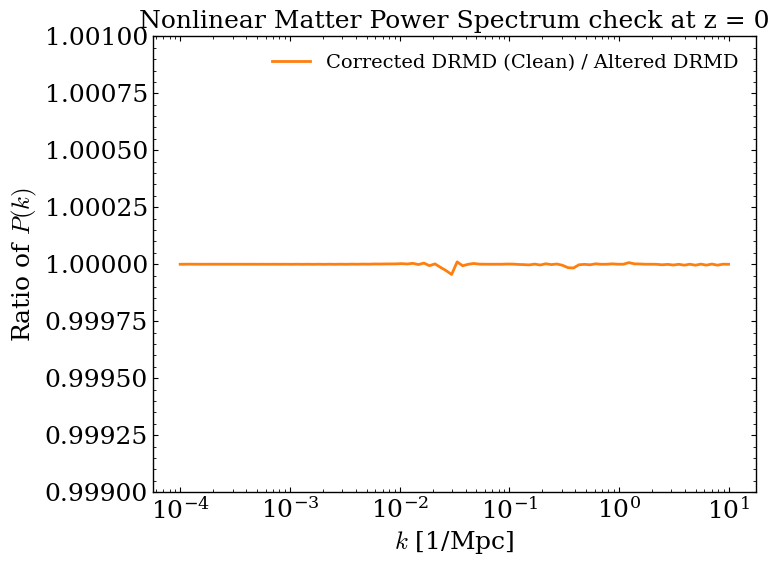

In [4]:
# Use the combined model to make the correction
k_vals = np.logspace(-4, 1, 100)  # 1/Mpc
correction = combined_full_model(k = k_vals, z = 0.0, dNeff_shift = 1.75, fidm_shift = -1.75)
# k_emu, emulator_correction = get_emulator_prediction(z=0.0, fidm=0.0, dNeff=0.0, )

# Extract the nonlinear matter power spectra at z=0 for all cosmologies
Pk_nl_clean_DRMD = np.array([cosmo_clean_DRMD.pk(ki, 0.0) for ki in k_vals])
Pk_nl_clean_LCDM = np.array([cosmo_clean_LCDM.pk(ki, 0.0) for ki in k_vals])
Pk_nl_altered_DRMD = np.array([cosmo_altered_DRMD.pk(ki, 0.0) for ki in k_vals])
Pk_nl_altered_LCDM = np.array([cosmo_altered_LCDM.pk(ki, 0.0) for ki in k_vals])
Pk_nl_corrected_DRMD = Pk_nl_clean_LCDM * correction['C']

# Make the same plot for the nonlinear power spectra
fig, ax = plt.subplots(figsize=(8, 6))
ax.semilogx(k_vals, Pk_nl_corrected_DRMD / Pk_nl_altered_DRMD, label='Corrected DRMD (Clean) / Altered DRMD', color='tab:orange')
ax.set_xlabel(r'$k$ [1/Mpc]')
ax.set_ylabel(r'Ratio of $P(k)$')
ax.set_title('Nonlinear Matter Power Spectrum check at z = 0')
ax.set_ylim(0.999, 1.001)
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# --- CONFIGURATION ---
N_grid = 512

# CONCEPT N-body Data Paths
input_dir_2048 = r"/home/storgaard/OneDrive/concept/grendel_output/2048/"
input_dir_256  = r"/home/storgaard/OneDrive/concept/grendel_output/256/"

model_name_lcdm = "planck"
model_name_drmd = "test_1"

# Calculate stitch points
k_nyq_2048 = np.pi / (2048 / N_grid)
k_nyq_256  = np.pi / (256 / N_grid)
k_transition = 0.1 * k_nyq_2048
k_max_small = 0.75 * k_nyq_256

def load_raw_pk(box_dir, model_name, z):
    """Loads raw P(k) files based on CONCEPT output naming convention."""
    a = 1 / (1 + z)
    filename = f"powerspec/powerspec_size512_lpt2_a={a:.3f}"
    filepath = os.path.join(box_dir, model_name, filename)
    df = pd.read_csv(filepath, sep=r'\s+', comment='#', header=None, usecols=[0, 1, 3], names=['k', 'modes', 'Pk'])
    return df

def stitch_spectra(df_large, df_small):
    """Stitches the 2048 and 256 box data."""
    # Large box up to transition
    large_mask = df_large['k'] <= k_transition
    part_1 = df_large[large_mask]
    
    # Small box after transition up to cutoff
    small_mask = (df_small['k'] > k_transition) & (df_small['k'] <= k_max_small) 
    part_2 = df_small[small_mask]
    
    return pd.concat([part_1, part_2], ignore_index=True)

def get_nbody_pk(model_name, z):
    """Wrapper to load and stitch a specific model and redshift."""
    df_256 = load_raw_pk(input_dir_256, model_name, z)
    df_2048 = load_raw_pk(input_dir_2048, model_name, z)
    return stitch_spectra(df_2048, df_256)

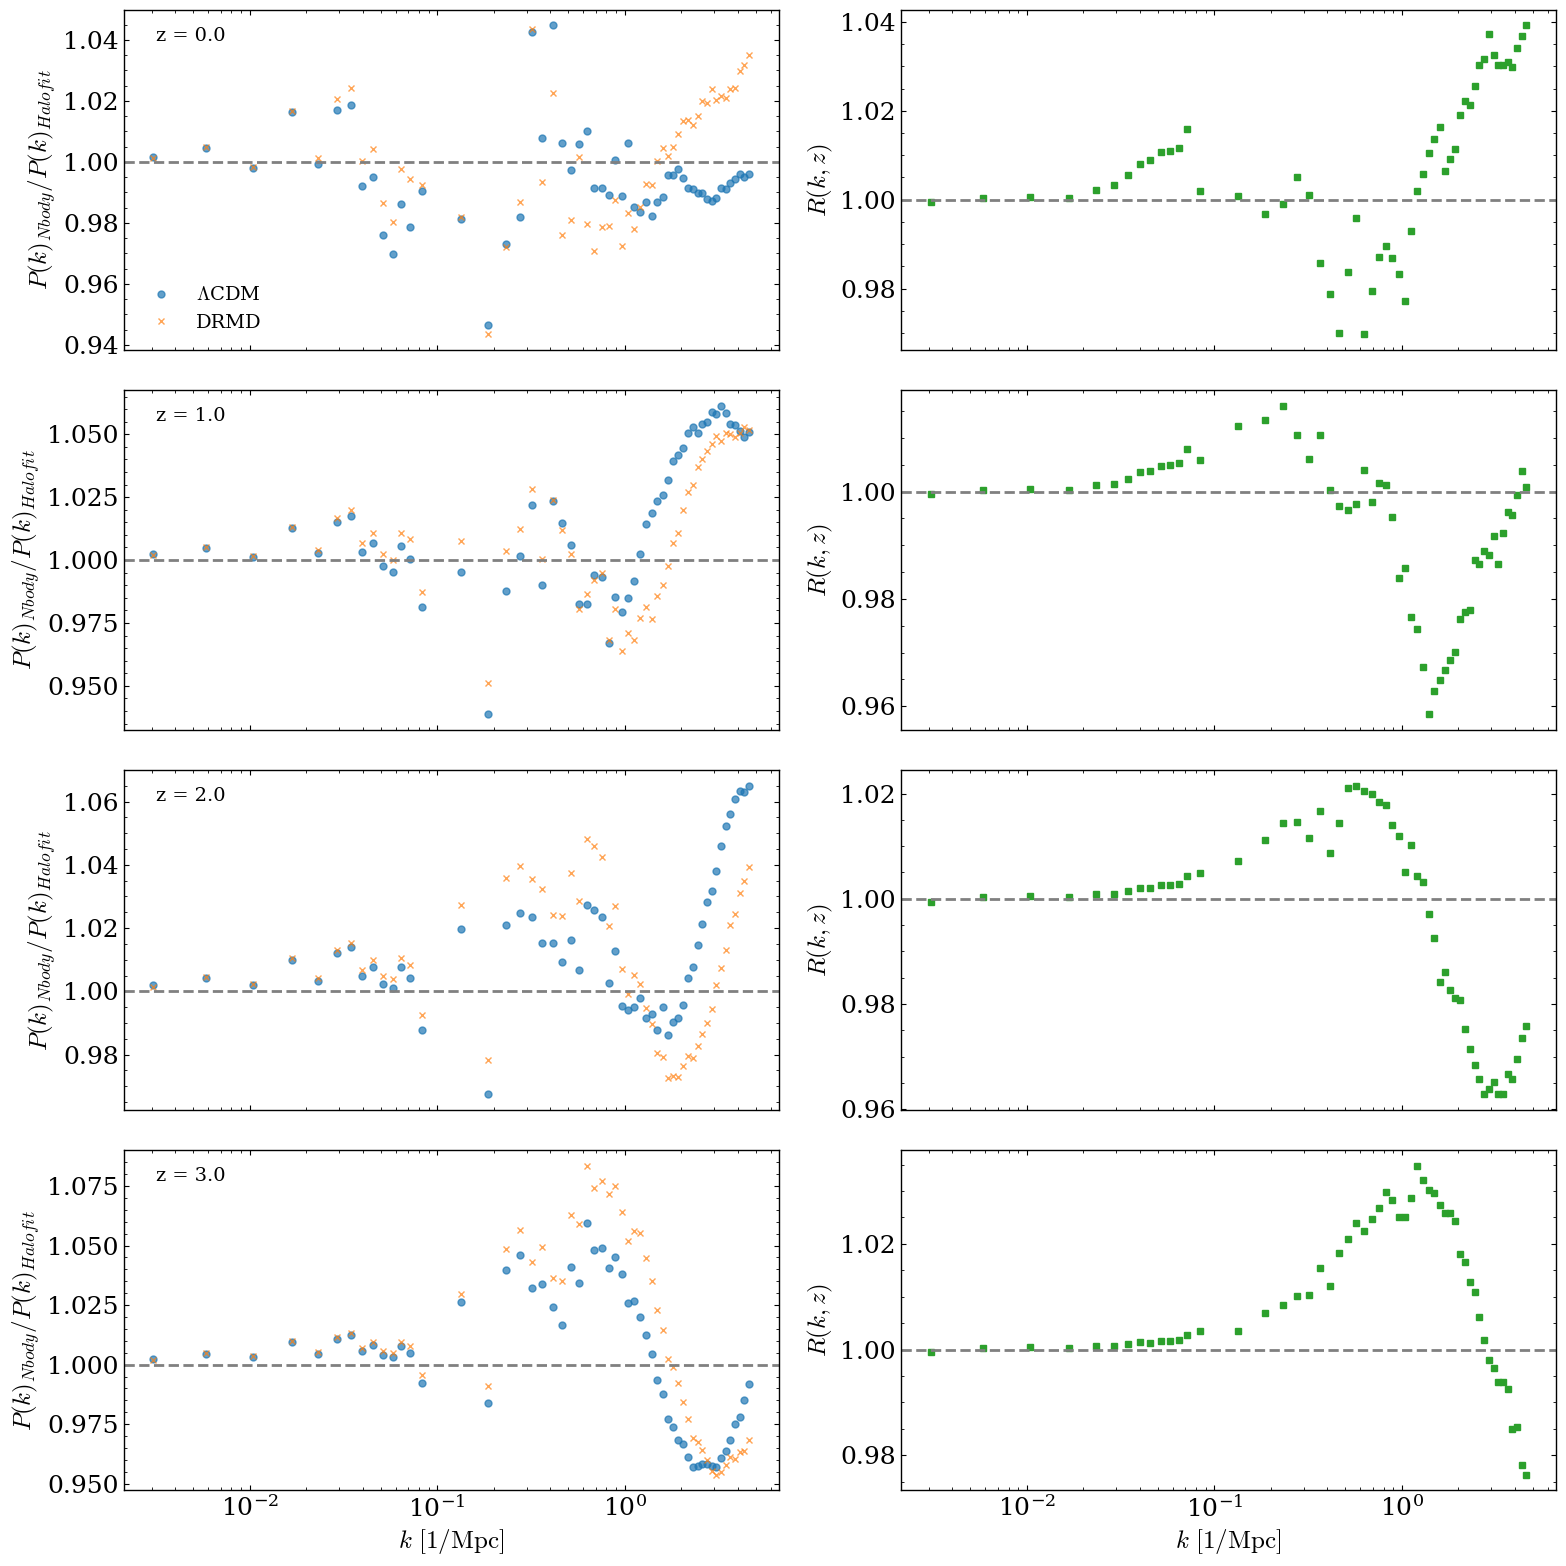

In [24]:
# Select representative redshifts to avoid clutter
z_to_plot = [0.0, 1.0, 2.0, 3.0]

fig, axes = plt.subplots(len(z_to_plot), 2, figsize=(16, 4 * len(z_to_plot)), sharex=True)

for i, z in enumerate(z_to_plot):
    # 1. Fetch N-body Data
    df_nbody_lcdm = get_nbody_pk(model_name_lcdm, z)
    df_nbody_drmd = get_nbody_pk(model_name_drmd, z)
    
    k_vals = df_nbody_lcdm['k'].values  # Assuming k bins align perfectly
    Pk_nbody_lcdm = df_nbody_lcdm['Pk'].values
    Pk_nbody_drmd = df_nbody_drmd['Pk'].values
    
    k_vals_emu, emulator_correction = get_emulator_prediction(z=z, fidm=0.0285 - 1.75 * 0.0076, dNeff=0.83 + 1.75 * 0.231 / 2, checkpoint_path="alsing_emulator_v1.pt")

    Pk_nl_fixed_LCDM = np.array([cosmo_clean_hmcode_LCDM.pk(ki, z) for ki in k_vals])
    Pk_nl_fixed_DRMD = np.array([cosmo_clean_hmcode_DRMD.pk(ki, z) for ki in k_vals])
    # Pk_nl_LCDM = np.array([cosmo_clean_LCDM.pk(ki, z) for ki in k_vals_emu])
    # Pk_nl_DRMD = Pk_nl_LCDM * emulator_correction 

    # 3. Calculate Ratios (N-body / Halofit)
    # Interpolate in log-log space using a cubic spline
    # interp_lcdm_log = interp1d(
    #     np.log10(k_vals), # <-- Changed from k_vals_emu
    #     np.log10(df_nbody_lcdm['Pk'].values), 
    #     kind='cubic', 
    #     bounds_error=False, 
    #     fill_value="extrapolate"
    # )
    # interp_drmd_log = interp1d(
    #     np.log10(k_vals), # <-- Changed from k_vals_emu
    #     np.log10(df_nbody_drmd['Pk'].values), 
    #     kind='cubic', 
    #     bounds_error=False, 
    #     fill_value="extrapolate"
    # )

    # Evaluate at the emulator k-values (length 25) and exponentiate back
    # Pk_nbody_lcdm_interp = 10**(interp_lcdm_log(np.log10(k_vals_emu)))
    # Pk_nbody_drmd_interp = 10**(interp_drmd_log(np.log10(k_vals_emu)))
    
    ratio_lcdm_my_CLASS = Pk_nbody_lcdm / Pk_nl_fixed_LCDM
    ratio_drmd_my_CLASS = Pk_nbody_drmd / Pk_nl_fixed_DRMD
    
    # 4. Plot 1: Absolute Disagreement (Left Column)
    ax1 = axes[i, 0]
    ax1.semilogx(k_vals, ratio_lcdm_my_CLASS, label=r'$\Lambda$CDM', color='tab:blue', marker='o', markersize=5, ls='None', alpha=0.7)
    ax1.semilogx(k_vals, ratio_drmd_my_CLASS, label=r'DRMD', color='tab:orange', marker='x', markersize=5, ls='None', alpha=0.7)
    if i == 0:
        ax1.legend()
    
    ax1.axhline(1.0, color='grey', linestyle='--')
    ax1.set_ylabel(f'$P(k)_{{Nbody}} / P(k)_{{Halofit}}$')
        
    # 5. Plot 2: The Double Ratio Comparison (Right Column)
    # Divides the DRMD error by the LCDM error to see if they deviate in the same way
    ax2 = axes[i, 1]
    double_ratio = ratio_drmd_my_CLASS / ratio_lcdm_my_CLASS
    
    ax2.semilogx(k_vals, double_ratio, color='tab:green', marker='s', markersize=5, ls='None')
    ax2.axhline(1.0, linestyle='--', color = 'grey')
    ax2.set_ylabel(r'$R(k,z)$')

    # Add text annotations for redshift
    ax1.text(0.05, 0.95, f'z = {z:.1f}', transform=ax1.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=14)

# Formatting X axes
axes[-1, 0].set_xlabel(r"$k \ [1/\mathrm{Mpc}]$")
axes[-1, 1].set_xlabel(r"$k \ [1/\mathrm{Mpc}]$")

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig("Ratio_of_Ratios_HMcode_test_1.pdf", dpi=300, bbox_inches='tight')

In [ ]:
# # Define wrappers so we do a completely fresh setup, compute, and cleanup for every run
# def run_clean_drmd():
#     temp_cosmo = Class()
#     temp_cosmo.set({**LCDM_params, **DRMD_params, 'nonlinear_verbose': 0})
#     temp_cosmo.compute()
#     # Prevent memory leaks in C-backend when looping
#     temp_cosmo.struct_cleanup()
#     temp_cosmo.empty()

# def run_altered_drmd():
#     temp_cosmo = Class_altered()
#     temp_cosmo.set({**LCDM_params, **DRMD_params, 'nonlinear_verbose': 0})
#     temp_cosmo.compute()
#     temp_cosmo.struct_cleanup()
#     temp_cosmo.empty()

# # Number of times to run each (keep it relatively low since CLASS takes a few seconds per run)
# n_runs = 0

# print(f"Timing Pristine CLASS DRMD (running {n_runs} times)...")
# clean_time = timeit.timeit(run_clean_drmd, number=n_runs)

# print(f"Timing Altered CLASS DRMD (running {n_runs} times)...")
# altered_time = timeit.timeit(run_altered_drmd, number=n_runs)

# # Calculate ratio
# ratio = altered_time / clean_time

# print("\n--- RESULTS ---")
# print(f"Pristine CLASS total time: {clean_time:.4f} s ({clean_time/n_runs:.4f} s per run)")
# print(f"Altered CLASS total time:  {altered_time:.4f} s ({altered_time/n_runs:.4f} s per run)")

# if ratio > 1:
#     print(f"-> Your Altered CLASS is {ratio:.2f}x SLOWER than the Pristine CLASS.")
# elif ratio < 1:
#     print(f"-> Your Altered CLASS is {1/ratio:.2f}x FASTER than the Pristine CLASS.")
# else:
#     print("-> Both CLASS versions took exactly the same amount of time.")

# # Print average time per run for clarity
# print(f"\nAverage time per run:")
# print(f"Pristine CLASS: {clean_time/n_runs:.4f} s")
# print(f"Altered CLASS:  {altered_time/n_runs:.4f} s")

In [ ]:
# Define wrappers so we do a completely fresh setup, compute, and cleanup for every run
def run_emulator():
    # Make the emulator prediction for the same parameters as the DRMD cosmology, but vary them slightly to test the emulator's speed as well
    fidm_value = 0.0285 + np.random.uniform(-0.005, 0.005)  # Vary fidm by ±0.005
    dNeff_value = 0.83 + np.random.uniform(-0.1, 0.1)  # Vary dNeff by ±0.1
    k_emu, emulator_correction = get_emulator_prediction(z=0.0, fidm=fidm_value, dNeff=dNeff_value, checkpoint_path="alsing_emulator_v1.pt")

# Number of times to run each (keep it relatively low since CLASS takes a few seconds per run)
n_runs = 1000

print(f"Timing Emulator (running {n_runs} times)...")
emulator_time = timeit.timeit(run_emulator, number=n_runs)

print("\n--- RESULTS ---")
print(f"Emulator total time: {emulator_time:.4f} s ({emulator_time/n_runs:.4f} s per run)")

Timing Emulator (running 1000 times)...

--- RESULTS ---
Emulator total time: 13.3396 s (0.0133 s per run)
